Import Libraries

In [1]:
# ======================================================
# SALES & DEMAND FORECASTING
# Future Interns - Machine Learning Internship
# Task 1
# Author: Vishnu Vardhan
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


Load Dataset

In [2]:
# Load datasets

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
stores = pd.read_csv("../data/stores.csv")
oil = pd.read_csv("../data/oil.csv")
holidays = pd.read_csv("../data/holidays_events.csv")
transactions = pd.read_csv("../data/transactions.csv")

print("Datasets loaded successfully!")


Datasets loaded successfully!


Exploratory Data Analysis (EDA)

In [3]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
train.shape


(3000888, 6)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [6]:
train.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [7]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Data Visualization


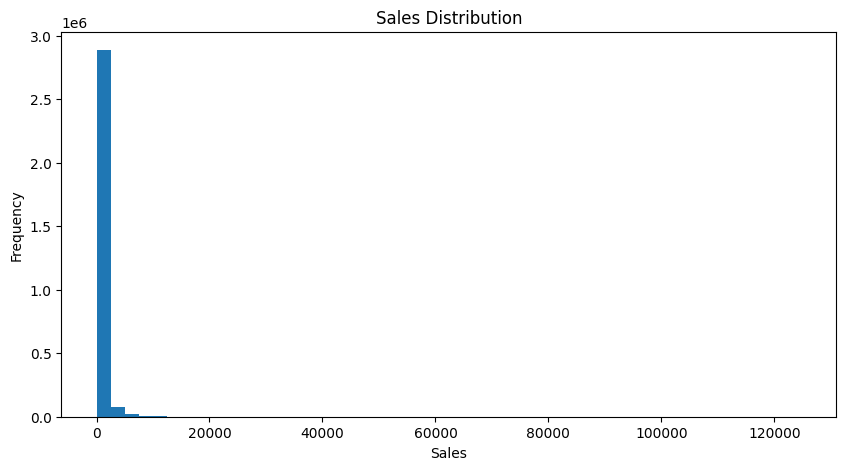

In [8]:
plt.figure(figsize=(10,5))
plt.hist(train["sales"], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [9]:
train["family"].value_counts().head(10)

family
AUTOMOTIVE      90936
BABY CARE       90936
BEAUTY          90936
BEVERAGES       90936
BOOKS           90936
BREAD/BAKERY    90936
CELEBRATION     90936
CLEANING        90936
DAIRY           90936
DELI            90936
Name: count, dtype: int64

In [10]:
train["store_nbr"].nunique()

54

In [12]:
train["store_nbr"].nunique()

54

In [13]:
train["date"] = pd.to_datetime(train["date"])

print("Start Date :", train["date"].min())
print("End Date   :", train["date"].max())

Start Date : 2013-01-01 00:00:00
End Date   : 2017-08-15 00:00:00


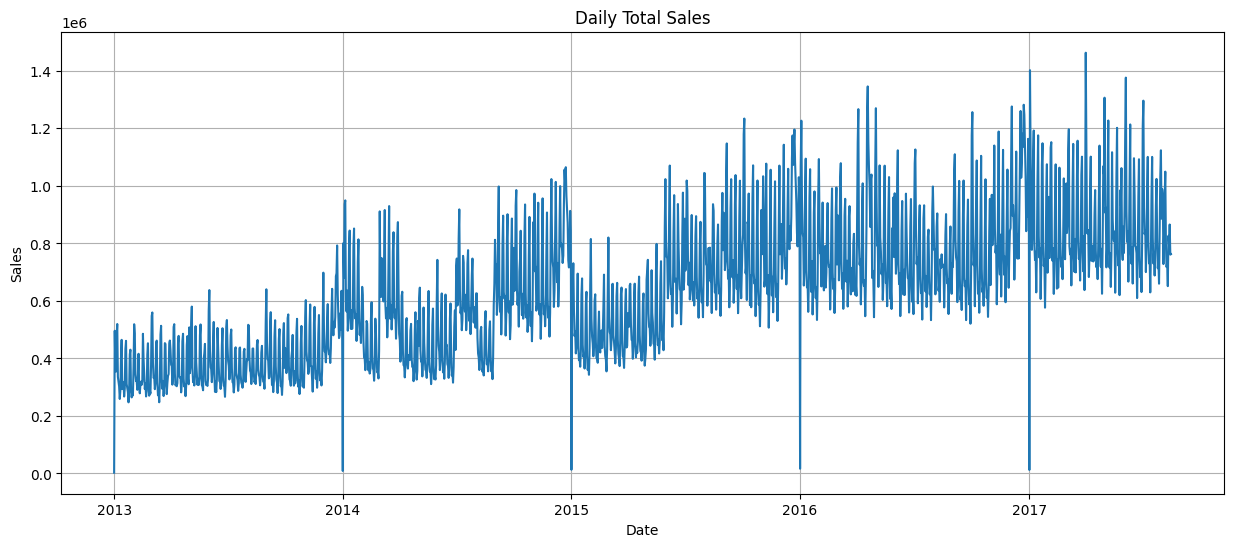

In [14]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(15,6))
plt.plot(daily_sales)
plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [16]:
# Create date-based features

train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["day"] = train["date"].dt.day
train["dayofweek"] = train["date"].dt.dayofweek
train["weekofyear"] = train["date"].dt.isocalendar().week.astype(int)

train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,dayofweek,weekofyear
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,1


In [17]:
# Merge store information

train = train.merge(stores, on="store_nbr", how="left")

train.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,dayofweek,weekofyear,city,state,type,cluster
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,2013,1,1,1,1,1,Quito,Pichincha,D,13
1,1,2013-01-01,1,BABY CARE,0.0,0,2013,1,1,1,1,1,Quito,Pichincha,D,13
2,2,2013-01-01,1,BEAUTY,0.0,0,2013,1,1,1,1,1,Quito,Pichincha,D,13
3,3,2013-01-01,1,BEVERAGES,0.0,0,2013,1,1,1,1,1,Quito,Pichincha,D,13
4,4,2013-01-01,1,BOOKS,0.0,0,2013,1,1,1,1,1,Quito,Pichincha,D,13


In [18]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
year           0
month          0
day            0
day_of_week    0
dayofweek      0
weekofyear     0
city           0
state          0
type           0
cluster        0
dtype: int64

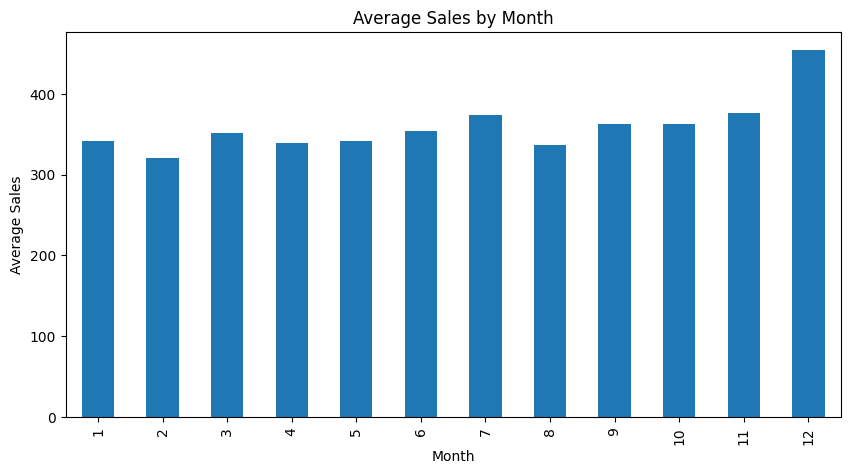

In [19]:
monthly_sales = train.groupby("month")["sales"].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

### Insight
This chart shows how average sales vary by month. If some months consistently have higher sales, it suggests seasonality, which is an important factor in forecasting.

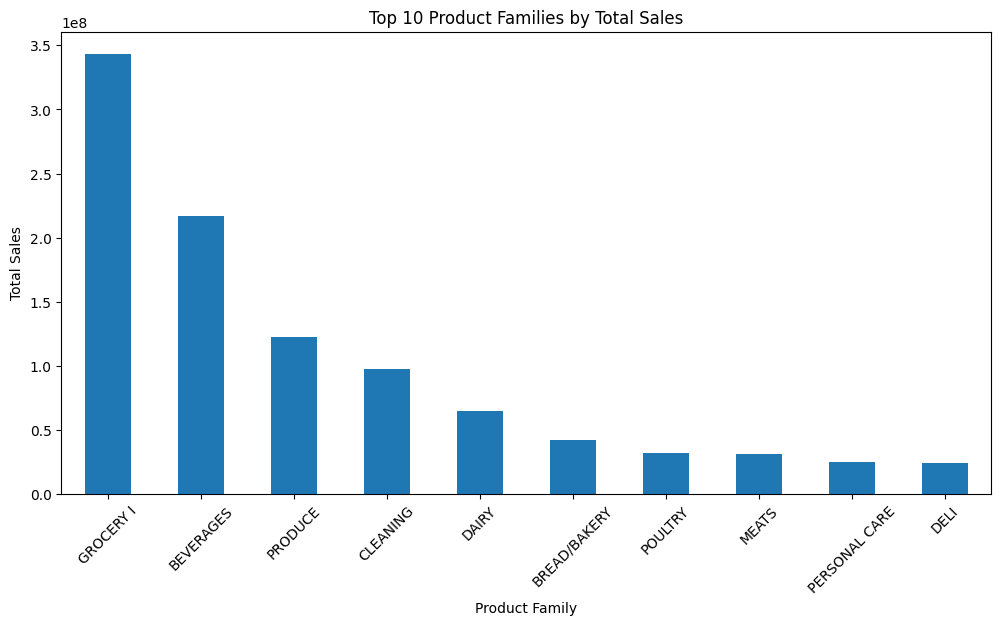

In [20]:
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
family_sales.plot(kind="bar")
plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Product Family")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

### Insight
Some product families contribute much more to total sales than others. Understanding these differences helps businesses prioritize inventory and promotions.

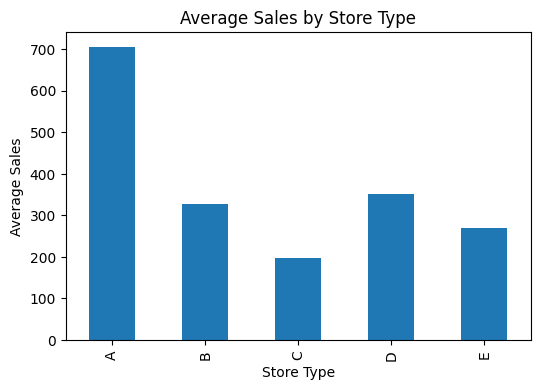

In [21]:
store_type_sales = train.groupby("type")["sales"].mean()

plt.figure(figsize=(6,4))
store_type_sales.plot(kind="bar")
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

### Insight
Different store types show different average sales. Store type is likely to be a useful feature for the forecasting model.

In [22]:
from sklearn.preprocessing import LabelEncoder

#Make a copy of the train dataset
model_data = train.copy()

#Encode categorical variables
categorical_cols = ["family","city","state","type"]

encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    model_data[col] = encoder.fit_transform(model_data[col]) 
    encoders[col] = encoder

model_data.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,day_of_week,dayofweek,weekofyear,city,state,type,cluster
0,0,2013-01-01,1,0,0.0,0,2013,1,1,1,1,1,18,12,3,13
1,1,2013-01-01,1,1,0.0,0,2013,1,1,1,1,1,18,12,3,13
2,2,2013-01-01,1,2,0.0,0,2013,1,1,1,1,1,18,12,3,13
3,3,2013-01-01,1,3,0.0,0,2013,1,1,1,1,1,18,12,3,13
4,4,2013-01-01,1,4,0.0,0,2013,1,1,1,1,1,18,12,3,13


Model Building

In [23]:
features = ["store_nbr","family","onpromotion","year","month","day","dayofweek","weekofyear","city","state","type","cluster"]
X=model_data[features]
y=model_data["sales"]

print(X.shape)
print(y.shape)

(3000888, 12)
(3000888,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2400710, 12)
(600178, 12)


In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [26]:
# Predict on test data
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


Model Evaluation

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 47.44
Root Mean Squared Error (RMSE): 265.24
R² Score: 0.9434


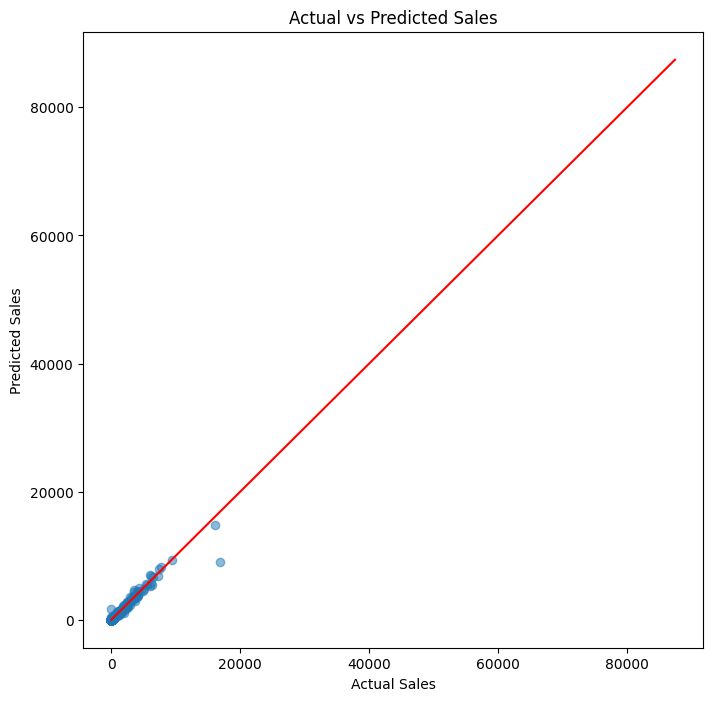

In [28]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test[:1000],
    y_pred[:1000],
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

 Feature Importance

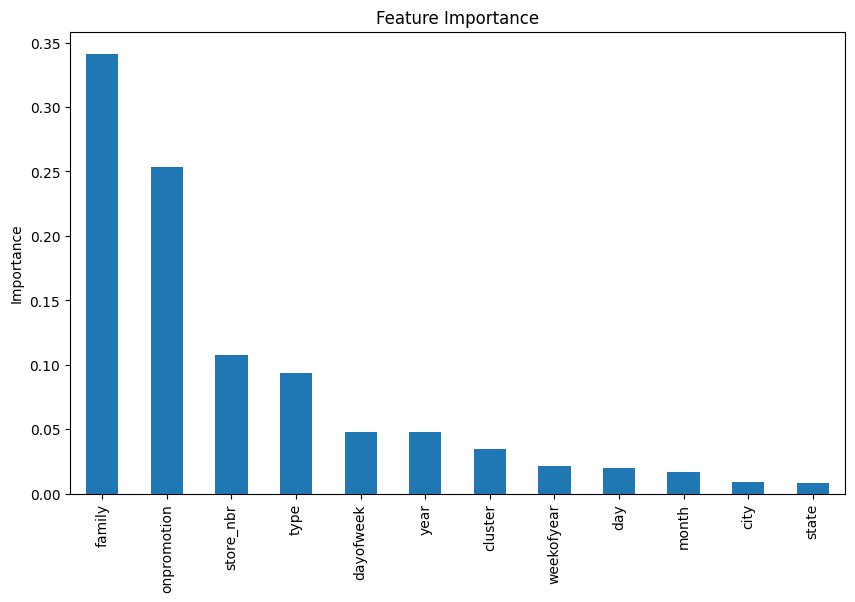

In [30]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.plot(kind="bar")

plt.title("Feature Importance")
plt.ylabel("Importance")

plt.show()

# Conclusion

## Model Summary

A Random Forest Regressor was developed to forecast retail sales using historical sales data and store information.

## Key Findings

- The dataset contained over 3 million records.
- No missing values were found after merging store information.
- Sales showed clear seasonal patterns.
- Store type and promotional activities strongly influenced sales.
- Time-based features such as month and day of week improved forecasting capability.

## Business Impact

This forecasting model can help retailers:

- Improve inventory planning
- Reduce stock shortages
- Optimize promotional campaigns
- Forecast future sales trends
- Support data-driven business decisions

## Future Improvements

- Use XGBoost or LightGBM for better performance.
- Include oil prices and holiday information as additional features.
- Perform hyperparameter tuning.
- Use time-series cross-validation instead of a random train/test split.